# AutoIF cross-class LPB analysis

This notebook analyzes the completed `construct_autoif_cross_class_calibrated_bound.py`
experiment without rerunning it. The survival model setup is fixed, calibration
examples come from **Programming & Technology**, and test examples come from
**Marketing & Social Media**. The central question is whether DAPRO retains the
requested coverage under this calibration-to-test class distribution shift.

## 1. Configuration and imports

In [1]:
from pathlib import Path
import json
import math
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# EXPERIMENT_NAME = "autoif_cross_class_setup-e5f9d85cff_calclass-7e65f8dbce_testclass-c23ba4d784_budget-20_cal-800_test-100_tau-0.56_gamma-10"
EXPERIMENT_NAME = "autoif_cross_class_setup-e5f9d85cff_calclass-7e65f8dbce_testclass-c23ba4d784_budget-20_cal-800_test-100_tau-0.56_gamma-10"

RESULTS_DIR = (
    PROJECT_ROOT / "results" / "merged_calibration_dfs" / EXPERIMENT_NAME
)
OUTPUT_DIR = RESULTS_DIR / "notebook_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = RESULTS_DIR / "all_df.csv"
PRIMARY_TARGET_COVERAGE = 0.90
TARGET_BUDGET_PER_SAMPLE = 20.0
CALIBRATION_SIZE = 800
EXPECTED_SEEDS = 50
DAPRO_NAME = "calibration_projected_optimization_platt_prob_allocation"
DISPLAY_NAMES = {
    "uncalibrated": "Uncalibrated",
    "oracle_survival_calibration": "Oracle calibration",
    "calibration_optimized_allocation": "Static allocation",
    "calibration_adaptive_optimized_allocation": "Locally adaptive",
    DAPRO_NAME: "DAPRO",
}
METHOD_ORDER = list(DISPLAY_NAMES.values())
COLORS = {
    "Uncalibrated": "#4C78A8",
    "Oracle calibration": "#72B7B2",
    "Static allocation": "#F58518",
    "Locally adaptive": "#E45756",
    "DAPRO": "#B279A2",
}
available_style = (
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "seaborn-whitegrid"
)
plt.style.use(available_style)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
})
print(f"Results: {RESULTS_DIR}")

Results: C:\Users\Shai1\Documents\projects\dapro_rebuttal\results\merged_calibration_dfs\autoif_cross_class_setup-e5f9d85cff_calclass-7e65f8dbce_testclass-c23ba4d784_budget-20_cal-800_test-100_tau-0.56_gamma-10


## 2. Load and validate the completed experiment

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Completed merged results are missing: {CSV_PATH}")
raw_state = {
    "size": CSV_PATH.stat().st_size,
    "mtime_ns": CSV_PATH.stat().st_mtime_ns,
}
raw_df = pd.read_csv(CSV_PATH)
exact_duplicate_count = int(raw_df.duplicated().sum())
all_df = raw_df.drop_duplicates().copy()
required_columns = {
    "seed", "calibration_name", "experiment_type", "dataset_name",
    "dataset_setup", "calibration_class", "test_class", "budget_used",
    "coverage", "size", "target_coverage",
}
missing = required_columns.difference(all_df.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

expected_metadata = {
    "experiment_type": "autoif_cross_class",
    "dataset_name": "dataset_autoif",
    "calibration_class": "Programming & Technology",
    "test_class": "Marketing & Social Media",
}
for column, expected in expected_metadata.items():
    observed = set(all_df[column].dropna().unique())
    if observed != {expected}:
        raise ValueError(
            f"Unexpected {column}: expected {expected!r}, observed {sorted(observed)!r}"
        )
if all_df["seed"].nunique() != EXPECTED_SEEDS:
    raise ValueError(
        f"Expected {EXPECTED_SEEDS} seeds, found {all_df['seed'].nunique()}."
    )
numeric = all_df[["budget_used", "coverage", "size", "target_coverage"]]
if not np.isfinite(numeric.to_numpy(dtype=float)).all():
    raise ValueError("Primary metric columns contain non-finite values.")
if not all_df["coverage"].between(0, 1).all():
    raise ValueError("Coverage values must be in [0, 1].")
print(
    f"Validated {len(all_df):,} unique rows, {all_df.seed.nunique()} seeds, "
    f"{all_df.target_coverage.nunique()} target levels, and "
    f"{all_df.calibration_name.nunique()} calibration methods."
)
print(f"Exact duplicate rows removed: {exact_duplicate_count}")
display(pd.Series(expected_metadata, name="value").to_frame())

Validated 26,950 unique rows, 50 seeds, 49 target levels, and 11 calibration methods.
Exact duplicate rows removed: 0


,value
experiment_type,autoif_cross_class
dataset_name,dataset_autoif
calibration_class,Programming & Technology
test_class,Marketing & Social Media


## 3. Recompute coverage, variance, LPB, and budget summaries

In [3]:
output_file = OUTPUT_DIR / "cross_class_method_summary_by_target.csv"

print(output_file)
print("Path length:", len(str(output_file)))
print("Directory exists:", OUTPUT_DIR.exists())

C:\Users\Shai1\Documents\projects\dapro_rebuttal\results\merged_calibration_dfs\autoif_cross_class_setup-e5f9d85cff_calclass-7e65f8dbce_testclass-c23ba4d784_budget-20_cal-800_test-100_tau-0.56_gamma-10\notebook_analysis\cross_class_method_summary_by_target.csv
Path length: 260
Directory exists: True


In [4]:
plot_df = all_df.loc[all_df.calibration_name.isin(DISPLAY_NAMES)].copy()
plot_df["Method"] = plot_df["calibration_name"].map(DISPLAY_NAMES)
plot_df["Coverage (%)"] = 100 * plot_df["coverage"]
plot_df["Target coverage (%)"] = 100 * plot_df["target_coverage"]
plot_df["Coverage gap (pp)"] = (
    plot_df["Coverage (%)"] - plot_df["Target coverage (%)"]
)
plot_df["Budget/sample"] = plot_df["budget_used"] / CALIBRATION_SIZE

summary_rows = []
for (method, target), group in plot_df.groupby(
    ["Method", "target_coverage"], observed=True
):
    summary_rows.append({
        "method": method,
        "target_coverage": float(target),
        "target_coverage_pct": float(100 * target),
        "n_seeds": int(group.seed.nunique()),
        "coverage_rate_pct": float(group["Coverage (%)"].mean()),
        "coverage_variance_pp2": float(group["Coverage (%)"].var(ddof=1)),
        "coverage_gap_pp": float(group["Coverage gap (pp)"].mean()),
        "mean_lpb_size": float(group["size"].mean()),
        "lpb_variance": float(group["size"].var(ddof=1)),
        "budget_consumed_per_sample": float(group["Budget/sample"].mean()),
        "fraction_seeds_at_or_above_target": float(
            (group.coverage >= target).mean()
        ),
    })
method_summary_by_target = pd.DataFrame(summary_rows)
from pathlib import Path

output_file = (
    OUTPUT_DIR / "cross_class_method_summary_by_target.csv"
).resolve()

long_output_file = Path(r"\\?\{}".format(output_file))

method_summary_by_target.to_csv(
    long_output_file,
    index=False,
    encoding="utf-8",
)

dapro_summary_by_target = method_summary_by_target.loc[
    method_summary_by_target.method.eq("DAPRO")
].sort_values("target_coverage").reset_index(drop=True)
dapro_summary_by_target.to_csv(
    OUTPUT_DIR / "cross_class_dapro_summary_by_target.csv", index=False
)
dapro_primary = dapro_summary_by_target.loc[
    np.isclose(
        dapro_summary_by_target.target_coverage,
        PRIMARY_TARGET_COVERAGE,
    )
].iloc[0]

## 4. Coverage and LPB size across requested targets

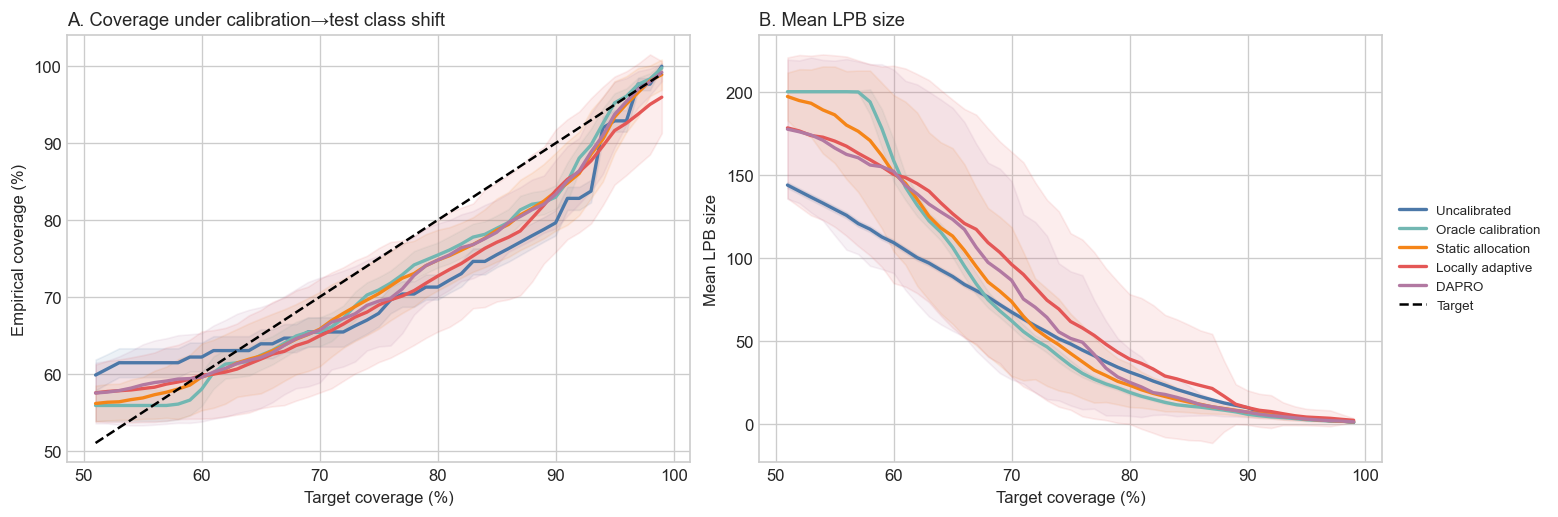

**Interpretation.** At the primary 90% target, DAPRO averages **83.34%** coverage (gap -6.66 pp) across 50 seeds. It therefore **does not attain the target on average** under this calibration-class to test-class shift. Shaded bands are ±1 across-seed standard deviation, not confidence intervals. The experiment uses one dataset with class-conditioned splits, so it does not establish performance under every form of distribution shift.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
for method in METHOD_ORDER:
    part = method_summary_by_target.loc[
        method_summary_by_target.method.eq(method)
    ].sort_values("target_coverage_pct")
    if part.empty:
        continue
    x = part["target_coverage_pct"].to_numpy()
    coverage = part["coverage_rate_pct"].to_numpy()
    coverage_sd = np.sqrt(part["coverage_variance_pp2"].to_numpy())
    size = part["mean_lpb_size"].to_numpy()
    size_sd = np.sqrt(part["lpb_variance"].to_numpy())
    axes[0].plot(
        x, coverage, label=method, color=COLORS[method], linewidth=2
    )
    axes[0].fill_between(
        x, coverage - coverage_sd, coverage + coverage_sd,
        color=COLORS[method], alpha=0.10,
    )
    axes[1].plot(
        x, size, label=method, color=COLORS[method], linewidth=2
    )
    axes[1].fill_between(
        x, size - size_sd, size + size_sd,
        color=COLORS[method], alpha=0.10,
    )
target_range = np.sort(plot_df["Target coverage (%)"].unique())
axes[0].plot(
    target_range, target_range, color="black", linestyle="--",
    linewidth=1.5, label="Target",
)
axes[0].set_title("A. Coverage under calibration→test class shift", loc="left")
axes[0].set_ylabel("Empirical coverage (%)")
axes[1].set_title("B. Mean LPB size", loc="left")
axes[1].set_ylabel("Mean LPB size")
for ax in axes:
    ax.set_xlabel("Target coverage (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
    frameon=False,
)
save_path1 = OUTPUT_DIR / "figure_autoif_cross_class_coverage_and_size.png"
long_output_file1 = Path(r"\\?\{}".format(OUTPUT_DIR))

fig.savefig(
    long_output_file1,
    dpi=300, bbox_inches="tight",
)
save_path2 = OUTPUT_DIR / "figure_autoif_cross_class_coverage_and_size.pdf"
long_output_file2 = Path(r"\\?\{}".format(save_path2))

fig.savefig(
    long_output_file2,
    bbox_inches="tight",
)
plt.show()

target_attained = dapro_primary.coverage_rate_pct >= 100 * PRIMARY_TARGET_COVERAGE
display(Markdown(
    f"**Interpretation.** At the primary {100 * PRIMARY_TARGET_COVERAGE:.0f}% "
    f"target, DAPRO averages **{dapro_primary.coverage_rate_pct:.2f}%** coverage "
    f"(gap {dapro_primary.coverage_gap_pp:+.2f} pp) across "
    f"{int(dapro_primary.n_seeds)} seeds. It therefore "
    f"**{'attains' if target_attained else 'does not attain'} the target on average** "
    "under this calibration-class to test-class shift. Shaded bands are ±1 "
    "across-seed standard deviation, not confidence intervals. The experiment uses "
    "one dataset with class-conditioned splits, so it does not establish performance "
    "under every form of distribution shift."
))

## 5. DAPRO diagnostics and OpenReview-ready tables

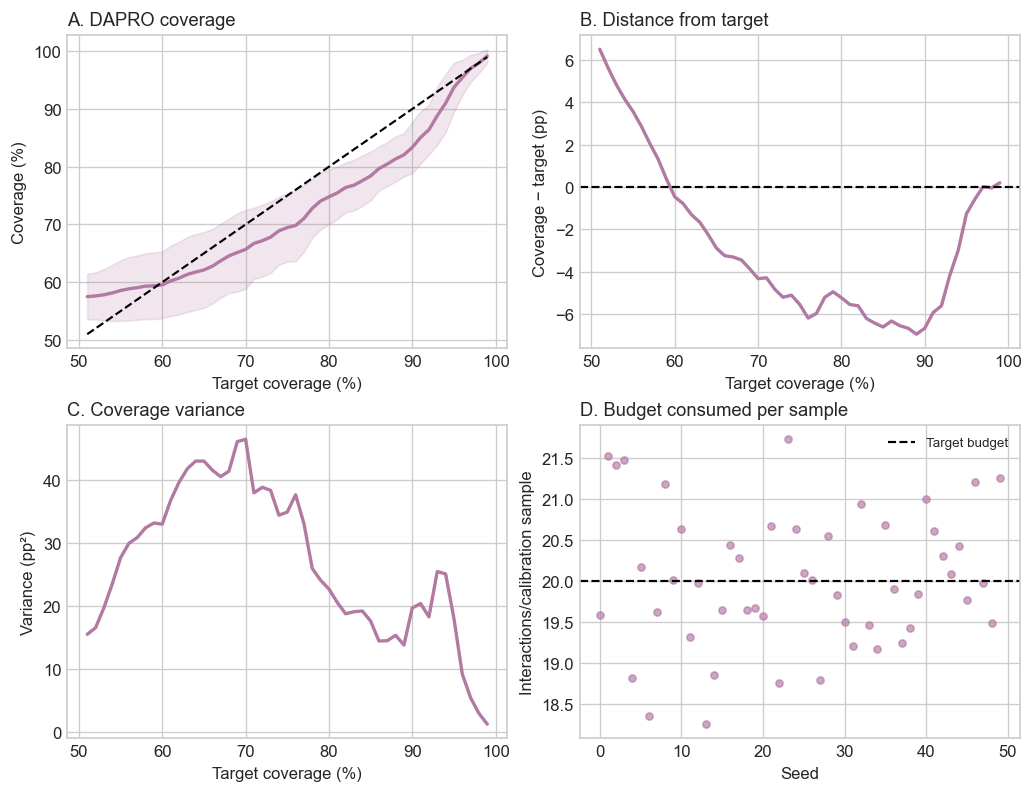

| DAPRO calibration→test shift | Target coverage | Coverage rate | Coverage variance (pp²) | LPB variance | Budget/sample | Seeds meeting target |
|---|---:|---:|---:|---:|---:|---:|
| Programming & Technology → Marketing & Social Media | 90.00% | 83.34% | 19.74 | 9.33 | 20.02 | 4% |

Variances are across 50 seeds. Budget is average interactions per calibration sample (`budget_used / 800`), not an aggregate total.

### Additional DAPRO targets

| Target | Coverage | 
|---:|---:|
| 80% | 74.78% |
| 90% | 83.34% |
| 95% | 93.74% |

### Additional DAPRO targets

| Target | Coverage | 
|---:|---:|
| 80% | 74.78% |
| 90% | 83.34% |
| 95% | 93.74% |


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), constrained_layout=True)
x = dapro_summary_by_target["target_coverage_pct"].to_numpy()
coverage = dapro_summary_by_target["coverage_rate_pct"].to_numpy()
coverage_sd = np.sqrt(
    dapro_summary_by_target["coverage_variance_pp2"].to_numpy()
)
axes[0, 0].plot(x, coverage, color=COLORS["DAPRO"], linewidth=2)
axes[0, 0].fill_between(
    x, coverage - coverage_sd, coverage + coverage_sd,
    color=COLORS["DAPRO"], alpha=0.18,
)
axes[0, 0].plot(x, x, color="black", linestyle="--", linewidth=1.3)
axes[0, 0].set_title("A. DAPRO coverage", loc="left")
axes[0, 0].set_ylabel("Coverage (%)")
axes[0, 1].plot(
    x, dapro_summary_by_target["coverage_gap_pp"],
    color=COLORS["DAPRO"], linewidth=2,
)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1.3)
axes[0, 1].set_title("B. Distance from target", loc="left")
axes[0, 1].set_ylabel("Coverage − target (pp)")
axes[1, 0].plot(
    x, dapro_summary_by_target["coverage_variance_pp2"],
    color=COLORS["DAPRO"], linewidth=2,
)
axes[1, 0].set_title("C. Coverage variance", loc="left")
axes[1, 0].set_ylabel("Variance (pp²)")
primary_seed_rows = plot_df.loc[
    plot_df.Method.eq("DAPRO")
    & np.isclose(plot_df.target_coverage, PRIMARY_TARGET_COVERAGE)
].sort_values("seed")
axes[1, 1].scatter(
    primary_seed_rows.seed,
    primary_seed_rows["Budget/sample"],
    color=COLORS["DAPRO"], s=18, alpha=0.65,
)
axes[1, 1].axhline(
    TARGET_BUDGET_PER_SAMPLE, color="black", linestyle="--",
    linewidth=1.3, label="Target budget",
)
axes[1, 1].set_title("D. Budget consumed per sample", loc="left")
axes[1, 1].set_ylabel("Interactions/calibration sample")
axes[1, 1].set_xlabel("Seed")
axes[1, 1].legend(frameon=False)
for ax in axes[0, :]:
    ax.set_xlabel("Target coverage (%)")
axes[1, 0].set_xlabel("Target coverage (%)")
fig.savefig(
    Path(r"\\?\{}".format(OUTPUT_DIR)) / "figure_autoif_cross_class_dapro_diagnostics.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    Path(r"\\?\{}".format(OUTPUT_DIR)) / "figure_autoif_cross_class_dapro_diagnostics.pdf",
    bbox_inches="tight",
)
plt.show()

dapro_primary_table = pd.DataFrame([{
    "shift": (
        f"{expected_metadata['calibration_class']} → "
        f"{expected_metadata['test_class']}"
    ),
    "target_coverage_pct": dapro_primary.target_coverage_pct,
    "coverage_rate_pct": dapro_primary.coverage_rate_pct,
    "coverage_gap_pp": dapro_primary.coverage_gap_pp,
    "coverage_variance_pp2": dapro_primary.coverage_variance_pp2,
    "lpb_variance": dapro_primary.lpb_variance,
    "budget_consumed_per_sample": dapro_primary.budget_consumed_per_sample,
    "fraction_seeds_at_or_above_target": (
        dapro_primary.fraction_seeds_at_or_above_target
    ),
    "n_seeds": int(dapro_primary.n_seeds),
}])
dapro_primary_table.to_csv(
    OUTPUT_DIR / "cross_class_dapro_target90_summary.csv", index=False
)
primary_md = "\n".join([
    (
        "| DAPRO calibration→test shift | Target coverage | Coverage rate | "
        "Coverage variance (pp²) | LPB variance | Budget/sample | Seeds meeting target |"
    ),
    "|---|---:|---:|---:|---:|---:|---:|",
    (
        f"| {dapro_primary_table.iloc[0]['shift']} | "
        f"{dapro_primary.target_coverage_pct:.2f}% | "
        f"{dapro_primary.coverage_rate_pct:.2f}% | "
        f"{dapro_primary.coverage_variance_pp2:.2f} | "
        f"{dapro_primary.lpb_variance:.2f} | "
        f"{dapro_primary.budget_consumed_per_sample:.2f} | "
        f"{dapro_primary.fraction_seeds_at_or_above_target:.0%} |"
    ),
    "",
    (
        "Variances are across 50 seeds. Budget is average interactions per "
        "calibration sample (`budget_used / 800`), not an aggregate total."
    ),
])
(Path(r"\\?\{}".format(OUTPUT_DIR)) / "cross_class_dapro_target90_summary.md").write_text(
    primary_md + "\n", encoding='utf-8'
)
display(Markdown(primary_md))

selected_targets = dapro_summary_by_target.loc[
    dapro_summary_by_target.target_coverage.isin([0.80, 0.90, 0.95])
]
selected_lines = [
    "| Target | Coverage | ",
    "|---:|---:|",
]
for _, row in selected_targets.iterrows():
    selected_lines.append(
        f"| {row.target_coverage_pct:.0f}% | {row.coverage_rate_pct:.2f}% |"
    )
selected_targets_md = "\n".join(selected_lines)
(OUTPUT_DIR / "cross_class_dapro_selected_targets.md").write_text(
    selected_targets_md + "\n"
)
display(Markdown("### Additional DAPRO targets\n\n" + selected_targets_md))
print(("### Additional DAPRO targets\n\n" + selected_targets_md))


## 6. Conclusion and reproducibility

In [12]:
attained_targets = int((dapro_summary_by_target.coverage_gap_pp >= 0).sum())
total_targets = len(dapro_summary_by_target)
conclusion = (
    f"DAPRO meets or exceeds the requested coverage on average at "
    f"{attained_targets}/{total_targets} evaluated target levels. At the primary "
    f"{100 * PRIMARY_TARGET_COVERAGE:.0f}% target, coverage is "
    f"{dapro_primary.coverage_rate_pct:.2f}% "
    f"({dapro_primary.coverage_gap_pp:+.2f} pp), so the saved experiment does "
    f"{'not ' if dapro_primary.coverage_gap_pp < 0 else ''}support target attainment "
    "under this specific calibration-to-test class shift."
)
display(Markdown(
    "**Conclusion.** " + conclusion
    + " This is a class-conditional distribution-shift result, not a guarantee "
    "for arbitrary shifts. The oracle calibration also uses the calibration-class "
    "distribution, so it is not an oracle for the shifted test-class distribution."
))

analysis_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "calibration_class": expected_metadata["calibration_class"],
    "test_class": expected_metadata["test_class"],
    "number_of_seeds": int(all_df.seed.nunique()),
    "number_of_target_levels": int(all_df.target_coverage.nunique()),
    "primary_target": float(PRIMARY_TARGET_COVERAGE),
    "dapro_primary": dapro_primary_table.iloc[0].to_dict(),
    "dapro_targets_attained_on_average": attained_targets,
    "dapro_total_targets": total_targets,
    "exact_duplicates_removed": exact_duplicate_count,
    "raw_experiment_rerun": False,
}
(OUTPUT_DIR / "analysis_summary.json").write_text(
    json.dumps(analysis_summary, indent=2, default=float)
)
final_state = {
    "size": CSV_PATH.stat().st_size,
    "mtime_ns": CSV_PATH.stat().st_mtime_ns,
}
assert final_state == raw_state
display(pd.Series({
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "platform": platform.platform(),
    "new_API_calls": False,
    "experiment_rerun": False,
}, name="value").to_frame())
print(conclusion)
print("Generated files:")
for generated_path in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {generated_path.name}")

**Conclusion.** DAPRO meets or exceeds the requested coverage on average at 11/49 evaluated target levels. At the primary 90% target, coverage is 83.34% (-6.66 pp), so the saved experiment does not support target attainment under this specific calibration-to-test class shift. This is a class-conditional distribution-shift result, not a guarantee for arbitrary shifts. The oracle calibration also uses the calibration-class distribution, so it is not an oracle for the shifted test-class distribution.

,value
Python,3.12.9
NumPy,2.1.2
pandas,2.2.3
platform,Windows-11-10.0.26200-SP0
new_API_calls,False
experiment_rerun,False


DAPRO meets or exceeds the requested coverage on average at 11/49 evaluated target levels. At the primary 90% target, coverage is 83.34% (-6.66 pp), so the saved experiment does not support target attainment under this specific calibration-to-test class shift.
Generated files:
  analysis_summary.json
  cross_class_dapro_selected_targets.md
  cross_class_dapro_summary_by_target.csv
  cross_class_dapro_target90_summary.csv
  cross_class_dapro_target90_summary.md
  cross_class_method_summary_by_target.csv
  figure_autoif_cross_class_coverage_and_size.pdf
  figure_autoif_cross_class_dapro_diagnostics.pdf
  figure_autoif_cross_class_dapro_diagnostics.png
